In [34]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
# from dynamic_routing_analysis import decoding_utils
# from dynamic_routing_analysis import plot_utils
# from dynamic_routing_analysis import spike_utils

import os
import pingouin as pg

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
# %matplotlib inline
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_2_blocks_out_crossval_10_units_strict_drift_20260609_231148/" #single session
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_2_blocks_out_half_block_shifts_crossval_20_units_strict_drift_20260616_221045/"
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_2_blocks_out_half_block_shifts_crossval_20_units_strict_drift_1/" 

results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_2_half_blocks_full_block_shifts_out_crossval_20_units_strict_drift_0/"
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_1_half_block_out_crossval_20_units_strict_drift_0/"


In [184]:
results = pl.scan_parquet(results_path).collect().to_pandas()

In [185]:
# sel_session = "742903_2024-10-22"
# results = pl.scan_parquet(results_path).filter(pl.col('session_id')==sel_session).collect().to_pandas()

In [186]:
results

,balanced_accuracy_test,balanced_accuracy_train,time_aligned_to,bin_size,sliding_window_size,bin_center,shift_idx,repeat_idx,labels,train_test_split_label,...,predict_proba_all_trials,trial_indices,unit_ids,coefs,is_all_trials,session_id,structure,electrode_group_names,unit_subsample_size,unit_criteria
0,0.465040,0.587070,stim_start_time,0.5,None,-0.25,NaN,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",None,...,"[0.11501937209988657, 0.16613310960027255, 0.4...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_D-1021, 670180_2023-07-27_D...","[0.5358172336402259, 0.0987721779017152, -0.24...",True,670180_2023-07-27,MOs,[probeD],20,strict_drift
1,0.405448,0.568344,stim_start_time,0.5,None,-0.25,NaN,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",None,...,"[0.2740408812753956, 0.41348188426462956, 0.58...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_D-1082, 670180_2023-07-27_D...","[0.12167856793078241, -0.7127756223095822, -0....",True,670180_2023-07-27,MOs,[probeD],20,strict_drift
2,0.483570,0.580052,stim_start_time,0.5,None,-0.25,NaN,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",None,...,"[0.10860130062178795, 0.15455255378461055, 0.4...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_D-1004, 670180_2023-07-27_D...","[-0.2719460853454232, 0.5320018817702734, -0.2...",True,670180_2023-07-27,MOs,[probeD],20,strict_drift
3,0.489799,0.586218,stim_start_time,0.5,None,-0.25,NaN,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",None,...,"[0.4884818976904389, 0.3101394361754009, 0.473...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_D-1021, 670180_2023-07-27_D...","[0.566245148508424, -0.2931981774336419, -0.16...",True,670180_2023-07-27,MOs,[probeD],20,strict_drift
4,0.429574,0.557357,stim_start_time,0.5,None,-0.25,NaN,4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",None,...,"[0.38133738501849723, 0.4442193203919843, 0.48...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_D-1021, 670180_2023-07-27_D...","[0.5326150427475315, 0.13431115427064658, -0.0...",True,670180_2023-07-27,MOs,[probeD],20,strict_drift
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,0.502213,0.591946,stim_start_time,0.5,None,-0.25,NaN,20,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",None,...,"[0.7184846291395384, 0.788459740171255, 0.7867...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_C-256, 670180_2023-07-27_C-...","[-0.28143935828697814, -0.015722325092795825, ...",True,670180_2023-07-27,VISp,[probeC],20,strict_drift
471,0.480779,0.590080,stim_start_time,0.5,None,-0.25,NaN,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",None,...,"[0.6572061275122274, 0.7782548679694509, 0.781...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_C-262, 670180_2023-07-27_C-...","[-0.04973930914876454, 0.020004722509768286, -...",True,670180_2023-07-27,VISp,[probeC],20,strict_drift
472,0.452648,0.568243,stim_start_time,0.5,None,-0.25,NaN,22,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",None,...,"[0.46603964640217654, 0.45862570026351646, 0.4...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_C-256, 670180_2023-07-27_C-...","[-0.2918911601984478, -0.9361261400687478, -0....",True,670180_2023-07-27,VISp,[probeC],20,strict_drift
473,0.492850,0.588296,stim_start_time,0.5,None,-0.25,NaN,23,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",None,...,"[0.6816248530307027, 0.7956378428592225, 0.807...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_C-256, 670180_2023-07-27_C-...","[-0.33257145176033226, -0.12760895378398704, -...",True,670180_2023-07-27,VISp,[probeC],20,strict_drift


In [187]:
sel_structure='MOs'



In [188]:
results.iloc[0]

balanced_accuracy_test                                                  0.46504
balanced_accuracy_train                                                 0.58707
time_aligned_to                                                 stim_start_time
bin_size                                                                    0.5
sliding_window_size                                                        None
bin_center                                                                -0.25
shift_idx                                                                   NaN
repeat_idx                                                                    0
labels                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
train_test_split_label                                                     None
train_set_indices             [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
train_trials                  [53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 6...
test_set_indices              [0, 0, 0, 

Text(0.5, 1.0, 'structure: ORBm, balanced accuracy: 0.65')

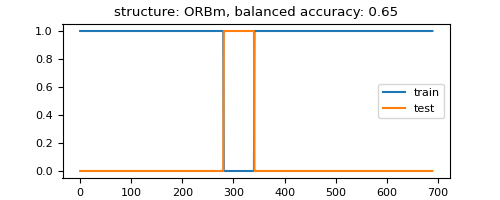

In [189]:
sel_row=84

sel_train_test_set=5
sel_test_set_indices=results['test_set_indices'].iloc[sel_row]==sel_train_test_set
sel_train_set_indices=results['train_set_indices'].iloc[sel_row]==sel_train_test_set

test_trial_numbers=results['test_trials'].iloc[sel_row][sel_test_set_indices]
train_trial_numbers=results['train_trials'].iloc[sel_row][sel_train_set_indices]

test_trial_vector=np.zeros(len(results['predict_proba'].iloc[sel_row]),dtype=bool)
train_trial_vector=np.zeros(len(results['predict_proba'].iloc[sel_row]),dtype=bool)

train_trial_vector[train_trial_numbers]=True
test_trial_vector[test_trial_numbers]=True

accuracy=results['balanced_accuracy_test_all'].iloc[sel_row][sel_train_test_set]
structure=results['structure'].iloc[sel_row]

fig,ax=plt.subplots(1,1,figsize=(5,2))
ax.plot(train_trial_vector,label='train')
ax.plot(test_trial_vector,label='test')
ax.legend()
ax.set_title(f'structure: {structure}, balanced accuracy: {accuracy:.2f}')

Text(0, 0.5, 'balanced accuracy')

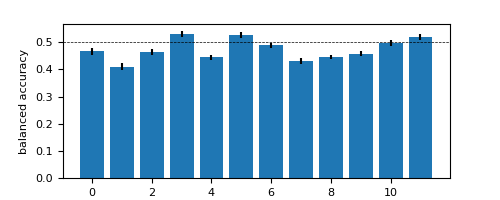

In [190]:
#get mean accuracy for each train-test set for a given structure
sel_structure='CA1'
if sel_structure=='all':
    structure_df=results.copy()
else:
    structure_df=results.query(f'structure=="{sel_structure}"')

balanced_accuracy_test_all=np.vstack(structure_df['balanced_accuracy_test_all'].values)
balanced_accuracy_test_mean=np.nanmean(balanced_accuracy_test_all,axis=0)
balanced_accuracy_test_sem=stats.sem(balanced_accuracy_test_all,axis=0,nan_policy='omit')

fig,ax=plt.subplots(1,1,figsize=(5,2))
ax.axhline(0.5,color='k',ls='--',lw=0.5)
# ax.errorbar(x=np.arange(len(balanced_accuracy_test_mean)),y=balanced_accuracy_test_mean,yerr=balanced_accuracy_test_sem)
ax.bar(x=np.arange(len(balanced_accuracy_test_mean)),height=balanced_accuracy_test_mean,yerr=balanced_accuracy_test_sem)
ax.set_xlabel('train-test set')
ax.set_ylabel('balanced accuracy')

In [191]:
np.mean(balanced_accuracy_test_mean)

0.4736075340318415

In [193]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
session_table=pl.read_parquet(session_table_path)

session_list=(
    session_table.filter(
    # pl.col('project')=="DynamicRouting",
    pl.col('project')=="Templeton",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

# block_dprime_threshold=1.0

# good_behavior_table={
#     'session_id':[],
#     'n_good_vis_blocks':[],
#     'n_good_aud_blocks':[],
# }

# for sel_session in session_list:
    
#     n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
#     n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)

#     good_behavior_table['session_id'].append(sel_session)
#     good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
#     good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)

# good_behavior_table=pd.DataFrame(good_behavior_table)
# session_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2')['session_id'].values

In [215]:
#select only relevant columns, then collect

# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_2_blocks_out_crossval_10_units_strict_drift_1/" #all sessions, with crossval trials saved
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_2_blocks_out_half_block_shifts_crossval_20_units_strict_drift_1/"
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_2_half_blocks_full_block_shifts_out_crossval_20_units_strict_drift_0/"
results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_1_half_block_out_crossval_20_units_strict_drift_0/"
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_2_blocks_out_half_block_shifts_wraparound_crossval_20_units_strict_drift_0/"

results = pl.scan_parquet(
    results_path
).filter(
    pl.col('session_id').is_in(session_list)
).select(['structure','balanced_accuracy_test_all','test_set_indices','train_set_indices','test_trials','train_trials','session_id']).collect().to_pandas()

In [216]:
results

,structure,balanced_accuracy_test_all,test_set_indices,train_set_indices,test_trials,train_trials,session_id
0,AUDpo,"[0.4482758620689655, 0.46551724137931033, 0.35...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6...",636397_2022-09-26
1,AUDpo,"[0.6206896551724138, 0.603448275862069, 0.2807...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6...",636397_2022-09-26
2,AUDpo,"[0.46551724137931033, 0.5862068965517241, 0.38...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6...",636397_2022-09-26
3,AUDpo,"[0.5, 0.4827586206896552, 0.43859649122807015,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6...",636397_2022-09-26
4,AUDpo,"[0.6379310344827587, 0.6379310344827587, 0.350...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6...",636397_2022-09-26
...,...,...,...,...,...,...,...
5120,VISp,"[0.5151515151515151, 0.3939393939393939, 0.333...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 4...",670248_2023-08-01
5121,VISp,"[0.48484848484848486, 0.42424242424242425, 0.6...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 4...",670248_2023-08-01
5122,VISp,"[0.45454545454545453, 0.45454545454545453, 0.4...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 4...",670248_2023-08-01
5123,VISp,"[0.5454545454545454, 0.42424242424242425, 0.62...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 4...",670248_2023-08-01


Text(0, 0.5, 'balanced accuracy')

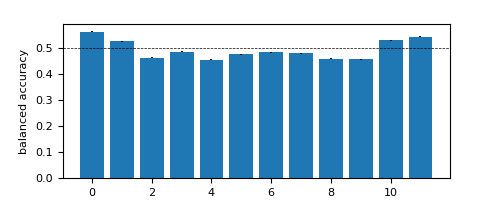

In [217]:
#get mean accuracy for each train-test set for a given structure
sel_structure='all'
if sel_structure=='all':
    structure_df=results.copy()
else:
    structure_df=results.query(f'structure=="{sel_structure}"')

balanced_accuracy_test_all=np.vstack(structure_df['balanced_accuracy_test_all'].values)
balanced_accuracy_test_mean=np.nanmean(balanced_accuracy_test_all,axis=0)
balanced_accuracy_test_sem=stats.sem(balanced_accuracy_test_all,axis=0,nan_policy='omit')

fig,ax=plt.subplots(1,1,figsize=(5,2))
ax.axhline(0.5,color='k',ls='--',lw=0.5)
# ax.errorbar(x=np.arange(len(balanced_accuracy_test_mean)),y=balanced_accuracy_test_mean,yerr=balanced_accuracy_test_sem)
ax.bar(x=np.arange(len(balanced_accuracy_test_mean)),height=balanced_accuracy_test_mean,yerr=balanced_accuracy_test_sem)
ax.set_xlabel('train-test set')
ax.set_ylabel('balanced accuracy')

In [218]:
np.mean(balanced_accuracy_test_mean)

0.4913444891223955

### testing out code for different crossval strategies

In [54]:
all_trials=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/trials.parquet').collect().to_pandas()

In [55]:
sel_session="742903_2024-10-22"
trials=all_trials.query(f'session_id=="{sel_session}"')

In [198]:

# train=[]
# test=[]
# # block_number=crossval_index
# block_number=trials['block_index'].values
# #find indices for block numbers, label second half of block as +0.5
# new_block_number=np.copy(block_number).astype(float)
# block_numbers=np.unique(block_number)
# for bb in block_numbers:
#     block_inds=np.where(block_number==bb)[0]
#     if len(block_inds)>0:
#         half_point=block_inds[len(block_inds)//2]
#         new_block_number[half_point:block_inds[-1]+1]=bb+0.5
# new_block_numbers=np.unique(new_block_number)

# for bb in new_block_numbers:
#     not_block_inds=np.where((new_block_number!=bb))[0]
#     train.append(not_block_inds)
#     block_inds=np.where((new_block_number==bb))[0]
#     test.append(block_inds)
# train_test_split=zip(train,test)

# train=[]
# test=[]
# # block_number=crossval_index
# block_number=trials['block_index'].values
# #find indices for block numbers, label second half of block as +0.5
# new_block_number=np.copy(block_number).astype(float)
# block_numbers=np.unique(block_number)
# for bb in block_numbers:
#     block_inds=np.where(block_number==bb)[0]
#     if len(block_inds)>0:
#         half_point=block_inds[len(block_inds)//2]
#         new_block_number[half_point:block_inds[-1]+1]=bb+0.5
# new_block_numbers=np.unique(new_block_number)

# loop_block_numbers=block_numbers+0.5

# for bb in loop_block_numbers[:-1]:
#     not_block_inds=np.where((new_block_number!=bb) & (new_block_number!=bb+0.5))[0]
#     train.append(not_block_inds)
#     block_inds=np.where((new_block_number==bb) | (new_block_number==bb+0.5))[0]
#     test.append(block_inds)
# #add first and last half-block
# not_block_inds=np.where(
#     (new_block_number!=loop_block_numbers[-1]) & (new_block_number!=block_numbers[0]))[0]
# train.append(not_block_inds)
# block_inds=np.where(
#     (new_block_number==loop_block_numbers[-1]) |(new_block_number==block_numbers[0]))[0]
# test.append(block_inds)

# train_test_split=zip(train,test)


train=[]
test=[]
# block_number=crossval_index
block_number=trials['block_index'].values
#find indices for block numbers, label second half of block as +0.5
new_block_number=np.copy(block_number).astype(float)
block_numbers=np.unique(block_number)
for bb in block_numbers:
    block_inds=np.where(block_number==bb)[0]
    if len(block_inds)>0:
        half_point=block_inds[len(block_inds)//2]
        new_block_number[half_point:block_inds[-1]+1]=bb+0.5
new_block_numbers=np.unique(new_block_number)

for bb in new_block_numbers:
    if bb+1.5 not in new_block_numbers:
        continue
    not_block_inds=np.where((new_block_number!=bb) & (new_block_number!=bb+0.5) & (new_block_number!=bb+1.0) & (new_block_number!=bb+1.5))[0]
    train.append(not_block_inds)
    block_inds=np.where((new_block_number==bb) | (new_block_number==bb+0.5) | (new_block_number==bb+1.0) | (new_block_number==bb+1.5))[0]
    test.append(block_inds)

#get wraparound train and test sets
for bb in [0,1,2]:
    not_block_inds=np.where(
        (new_block_number!=new_block_numbers[-3+bb]) & (new_block_number!=new_block_numbers[-2+bb]) &
        (new_block_number!=new_block_numbers[-1+bb]) & (new_block_number!=new_block_numbers[0+bb]))[0]
    train.append(not_block_inds)
    block_inds=np.where(
        (new_block_number==new_block_numbers[-3+bb]) |(new_block_number==new_block_numbers[-2+bb]) | 
        (new_block_number==new_block_numbers[-1+bb]) | (new_block_number==new_block_numbers[0+bb]))[0]
    test.append(block_inds)

train_test_split=zip(train,test)

ypred_proba_all=[]
decision_function_all=[]

In [127]:
# bb
# np.where(block_number==bb)[0]
# block_number

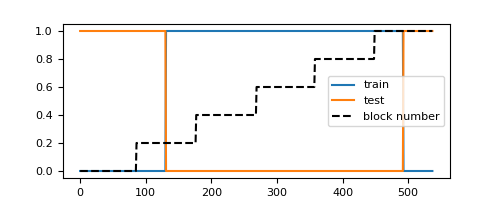

In [206]:
sel_train_test_set=11
test_set_indices=test[sel_train_test_set]
train_set_indices=train[sel_train_test_set]

test_trial_vector=np.zeros(len(block_number),dtype=bool)
train_trial_vector=np.zeros(len(block_number),dtype=bool)

train_trial_vector[train_set_indices]=True
test_trial_vector[test_set_indices]=True

# accuracy=results['balanced_accuracy_test_all'].iloc[sel_row][sel_train_test_set]
# structure=results['structure'].iloc[sel_row]

fig,ax=plt.subplots(1,1,figsize=(5,2))
ax.plot(train_trial_vector,label='train')
ax.plot(test_trial_vector,label='test')
ax.plot(block_number/np.max(block_number),label='block number',color='k',ls='--')
ax.legend()
# ax.set_title(f'structure: {structure}, balanced accuracy: {accuracy:.2f}')